# **Hyperparameter Optimization & Training Analysis**
Stable Version for Copying

## Hyperparameter Optimization Analysis

In [12]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import sys
import optuna
import yaml
import numpy as np
from pathlib import Path
import optuna.visualization.matplotlib as ovis

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

try:
    from config import RUNS_DIR
except ImportError:
    print("Warning: Could not import RUNS_DIR. Ensure config.py is in the root directory.")


STUDY_FOLDER = "acne_hparam_study_v3.2"
STUDY_PREFIX = "acne_hparam_search_v3.2_trial_"
study_path = RUNS_DIR / STUDY_FOLDER

In [13]:
records = []

if not study_path.exists():
    raise FileNotFoundError(f"Check paths. Could not find: {study_path}")

for trial_dir in study_path.glob(f"{STUDY_PREFIX}*"):
    args_path = trial_dir / "args.yaml"
    results_path = trial_dir / "results.csv"

    if not args_path.exists() or not results_path.exists():
        continue

    # Load params
    with open(args_path, "r") as f:
        args = yaml.safe_load(f)

    # Load metrics
    df = pd.read_csv(results_path)
    if df.empty:
        continue

    df.columns = [c.strip() for c in df.columns]
    final_row = df.iloc[-1]

    #  f1-score from last epoch 
    p = final_row.get("metrics/precision(B)", 0)
    r = final_row.get("metrics/recall(B)", 0)
    f1 = 2 * (p * r) / (p + r + 1e-8) if (p + r) > 0 else 0

    record = {
        "trial": trial_dir.name,
        "map50": final_row.get("metrics/mAP50(B)", None),
        "map50_95": final_row.get("metrics/mAP50-95(B)", None),
        "precision": p,
        "recall": r,
        "f1_score": f1,

        "optimizer": args.get("optimizer"),
        "lr0": args.get("lr0"),
        "weight_decay": args.get("weight_decay"),
        "mosaic": args.get("mosaic"),
        "mixup": args.get("mixup"),
        "hsv_s": args.get("hsv_s"),
        "hsv_v": args.get("hsv_v"),
        "scale": args.get("scale"),
    }

    records.append(record)

results = pd.DataFrame(records)
print(f"Loaded {len(results)} trials from {STUDY_FOLDER}")

Loaded 15 trials from acne_hparam_study_v3.2


In [14]:
print("\nTop 10 Trials by mAP50:")
top_trials = results.sort_values("map50", ascending=False).head(10)
display(top_trials)

top_5_trials = top_trials.head(5)


Top 10 Trials by mAP50:


,trial,map50,map50_95,precision,recall,f1_score,optimizer,lr0,weight_decay,mosaic,mixup,hsv_s,hsv_v,scale
3,acne_hparam_search_v3.2_trial_14,0.44363,0.16868,0.53724,0.43732,0.482158,MuSGD,0.001258,0.005158,0.205482,0.074734,0.001234,0.018702,0.107752
11,acne_hparam_search_v3.2_trial_6,0.43984,0.16936,0.51982,0.44706,0.480702,AdamW,0.002361,0.000792,0.246896,0.017747,0.031017,0.006971,0.221733
1,acne_hparam_search_v3.2_trial_1,0.43329,0.16334,0.51572,0.43792,0.473646,AdamW,0.000403,0.001048,0.526933,0.119191,0.038892,0.037965,0.314309
8,acne_hparam_search_v3.2_trial_3,0.43008,0.16459,0.49077,0.45245,0.470832,AdamW,0.001798,0.000104,0.578073,0.089667,0.044401,0.014490,0.241163
0,acne_hparam_search_v3.2_trial_0,0.42697,0.16430,0.50265,0.43642,0.467199,MuSGD,0.001432,0.003347,0.500697,0.097119,0.046617,0.022929,0.364751
7,acne_hparam_search_v3.2_trial_2,0.42602,0.16473,0.49574,0.43238,0.461897,AdamW,0.001120,0.000746,0.449755,0.133781,0.017965,0.041756,0.536429
10,acne_hparam_search_v3.2_trial_5,0.42600,0.16014,0.50469,0.44855,0.474967,AdamW,0.000579,0.001264,0.664380,0.010320,0.031790,0.019124,0.118447
4,acne_hparam_search_v3.2_trial_15,0.42473,0.16533,0.49006,0.43870,0.462960,MuSGD,0.001834,0.002075,0.466192,0.064207,0.023558,0.012368,0.591419
2,acne_hparam_search_v3.2_trial_13,0.42343,0.16043,0.51321,0.42414,0.464443,MuSGD,0.001384,0.002470,0.362463,0.031655,0.038329,0.011431,0.119261
9,acne_hparam_search_v3.2_trial_4,0.42097,0.16167,0.48992,0.44564,0.466732,AdamW,0.002896,0.000143,0.346985,0.064675,0.003623,0.038635,0.235474


In [ ]:
stability_records = []

# Iterate through directories to fetch full epoch history
for trial_dir in study_path.glob(f"{STUDY_PREFIX}*"):
    args_path = trial_dir / "args.yaml"
    results_path = trial_dir / "results.csv"

    if not args_path.exists() or not results_path.exists():
        continue

    with open(args_path, "r") as f:
        args = yaml.safe_load(f)

    df = pd.read_csv(results_path)
    if df.empty or len(df) < 5:  # Skip broken/interrupted trials
        continue

    df.columns = [c.strip() for c in df.columns]
    
    # 1. Final metrics
    final_row = df.iloc[-1]
    p = final_row.get("metrics/precision(B)", 0)
    r = final_row.get("metrics/recall(B)", 0)
    f1_final = 2 * (p * r) / (p + r + 1e-8) if (p + r) > 0 else 0
    
    # 2. Stability Analysis (Focusing on the last 40% of the training run)
    tail_size = int(len(df) * 0.4)
    tail_df = df.tail(tail_size)
    
    # Standard deviation of the tail (lower means smoother plateau)
    map50_std_tail = tail_df["metrics/mAP50(B)"].std()
    
    # Late Trend: compares the second half of the tail vs the first half of the tail
    half_tail = int(tail_size / 2)
    trend = tail_df["metrics/mAP50(B)"].tail(half_tail).mean() - tail_df["metrics/mAP50(B)"].head(half_tail).mean()

    # 3. Aggregate only Optimizer info and Stability Metrics
    # Handling potential missing optimizer info due to our dynamic database hot-fix
    opt_v1 = args.get("optimizer")
    optimizer_name = opt_v1 if opt_v1 else "MuSGD (Locked)"

    stability_records.append({
        "trial_name": trial_dir.name,
        "optimizer": optimizer_name,
        "final_mAP50": final_row.get("metrics/mAP50(B)", 0),
        "final_f1": round(f1_final, 5),
        "total_epochs": len(df),
        "tail_mAP50_std": round(map50_std_tail, 4) if not np.isnan(map50_std_tail) else None,
        "late_trend": round(trend, 4) if not np.isnan(trend) else None,
        "max_mAP50_epoch": df["metrics/mAP50(B)"].idxmax() + 1 if "metrics/mAP50(B)" in df else None
    })

# Create clean DataFrame for quick stability diagnostics
df_stability = pd.DataFrame(stability_records)
df_stability["late_trend_abs"] = df_stability["late_trend"].abs()
df_stability_sorted = df_stability.sort_values(
    by=["tail_mAP50_std", "late_trend_abs"], 
    ascending=[True, True]
)

df_stability_sorted = df_stability_sorted.drop(columns=["late_trend_abs"])

print("TRIALS SORTED BY STABILITY (Most stable first):")
display(df_stability_sorted)




# STABILITY METRICS GUIDE 

# 1. tail_mAP50_std (End-game noise -> LOWER is better)
#    - Measures performance fluctuations over the last 40% of epochs.
#    - < 0.005: Perfect. Rock-solid, stable plateau.
#    - > 0.015: Highly volatile. Model is jumping up/down, final score is just luck.
#
# 2. late_trend (End-game direction -> CLOSER TO ZERO is better)
#    - Shows what the model was doing at the very end of training.
#    - Positive (> +0.015): Still climbing. Training was cut off too early.
#    - Near Zero (+/- 0.002): Perfect convergence. Model stabilized beautifully.
#    - Negative (< -0.010): Performance dropping. Overfitting has started.
#
# 3. max_mAP50_epoch vs total_epochs (Peak performance moment)
#    - Identifies the exact epoch where the model hit its highest score.
#    - If peak happens way before the end (e.g., epoch 33/50): Remaining epochs 
#      were wasted, and the model plateaued too early.

TRIALS SORTED BY STABILITY (Most stable first):


,trial_name,optimizer,final_mAP50,final_f1,total_epochs,tail_mAP50_std,late_trend,max_mAP50_epoch
14,acne_hparam_search_v3.2_trial_9,AdamW,0.38690,0.44161,50,0.0031,0.0034,42
0,acne_hparam_search_v3.2_trial_0,MuSGD,0.42697,0.46720,50,0.0046,0.0020,39
10,acne_hparam_search_v3.2_trial_5,AdamW,0.42600,0.47497,50,0.0056,0.0036,33
12,acne_hparam_search_v3.2_trial_7,AdamW,0.40079,0.45292,44,0.0057,0.0050,34
13,acne_hparam_search_v3.2_trial_8,MuSGD,0.40672,0.45004,50,0.0061,0.0060,45
4,acne_hparam_search_v3.2_trial_15,MuSGD,0.42473,0.46296,50,0.0062,0.0077,47
1,acne_hparam_search_v3.2_trial_1,AdamW,0.43329,0.47365,46,0.0081,0.0043,38
3,acne_hparam_search_v3.2_trial_14,MuSGD,0.44363,0.48216,50,0.0087,0.0141,47
11,acne_hparam_search_v3.2_trial_6,AdamW,0.43984,0.48070,50,0.0090,0.0119,43
7,acne_hparam_search_v3.2_trial_2,AdamW,0.42602,0.46190,48,0.0113,0.0105,43


In [16]:
# CORRELATION ANALYSIS 
numeric_cols = [
    "lr0",
    "weight_decay",
    "mosaic",
    "mixup",
    "hsv_s",
    "hsv_v",
    "scale",
    "map50"
]

existing_cols = [c for c in numeric_cols if c in results.columns]
corr = results[existing_cols].corr()

print("\nCorrelation with mAP50:")
display(corr["map50"].sort_values(ascending=False))


Correlation with mAP50:


map50           1.000000
weight_decay    0.332703
hsv_v           0.136008
lr0             0.110933
mosaic         -0.004413
scale          -0.030678
hsv_s          -0.047923
mixup          -0.359345
Name: map50, dtype: float64

In [17]:
# BEST TRIAL SUMMARY 

print("BEST TRIAL (Highest mAP50)\n")

best = results.sort_values("map50", ascending=False).iloc[0]
print(best)

BEST TRIAL (Highest mAP50)

trial           acne_hparam_search_v3.2_trial_14
map50                                    0.44363
map50_95                                 0.16868
precision                                0.53724
recall                                   0.43732
f1_score                                0.482158
optimizer                                  MuSGD
lr0                                     0.001258
weight_decay                            0.005158
mosaic                                  0.205482
mixup                                   0.074734
hsv_s                                   0.001234
hsv_v                                   0.018702
scale                                   0.107752
Name: 3, dtype: object


In [18]:
# BEST TRIAL SUMMARY 

print("BEST TRIAL (Highest Recall)\n")

best = results.sort_values("recall", ascending=False).iloc[0]
print(best)

BEST TRIAL (Highest Recall)

trial           acne_hparam_search_v3.2_trial_3
map50                                   0.43008
map50_95                                0.16459
precision                               0.49077
recall                                  0.45245
f1_score                               0.470832
optimizer                                 AdamW
lr0                                    0.001798
weight_decay                           0.000104
mosaic                                 0.578073
mixup                                  0.089667
hsv_s                                  0.044401
hsv_v                                   0.01449
scale                                  0.241163
Name: 8, dtype: object



Comprehensive Metric and Loss Profiles for Top 5 Trials


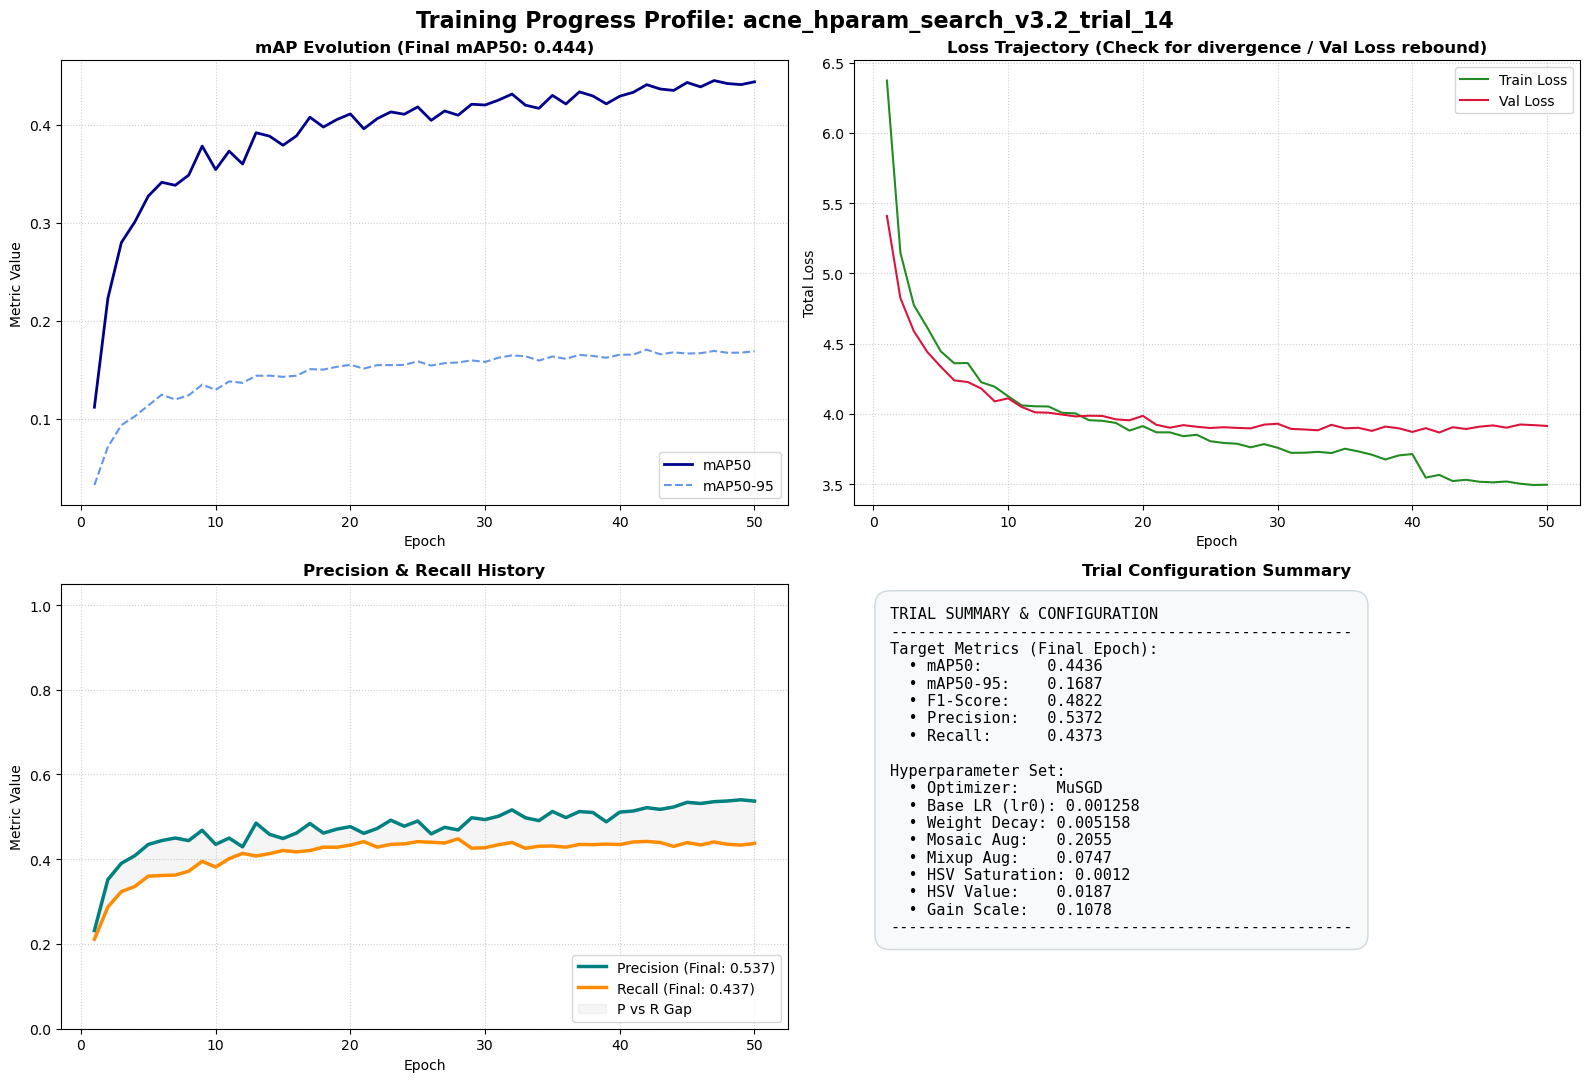

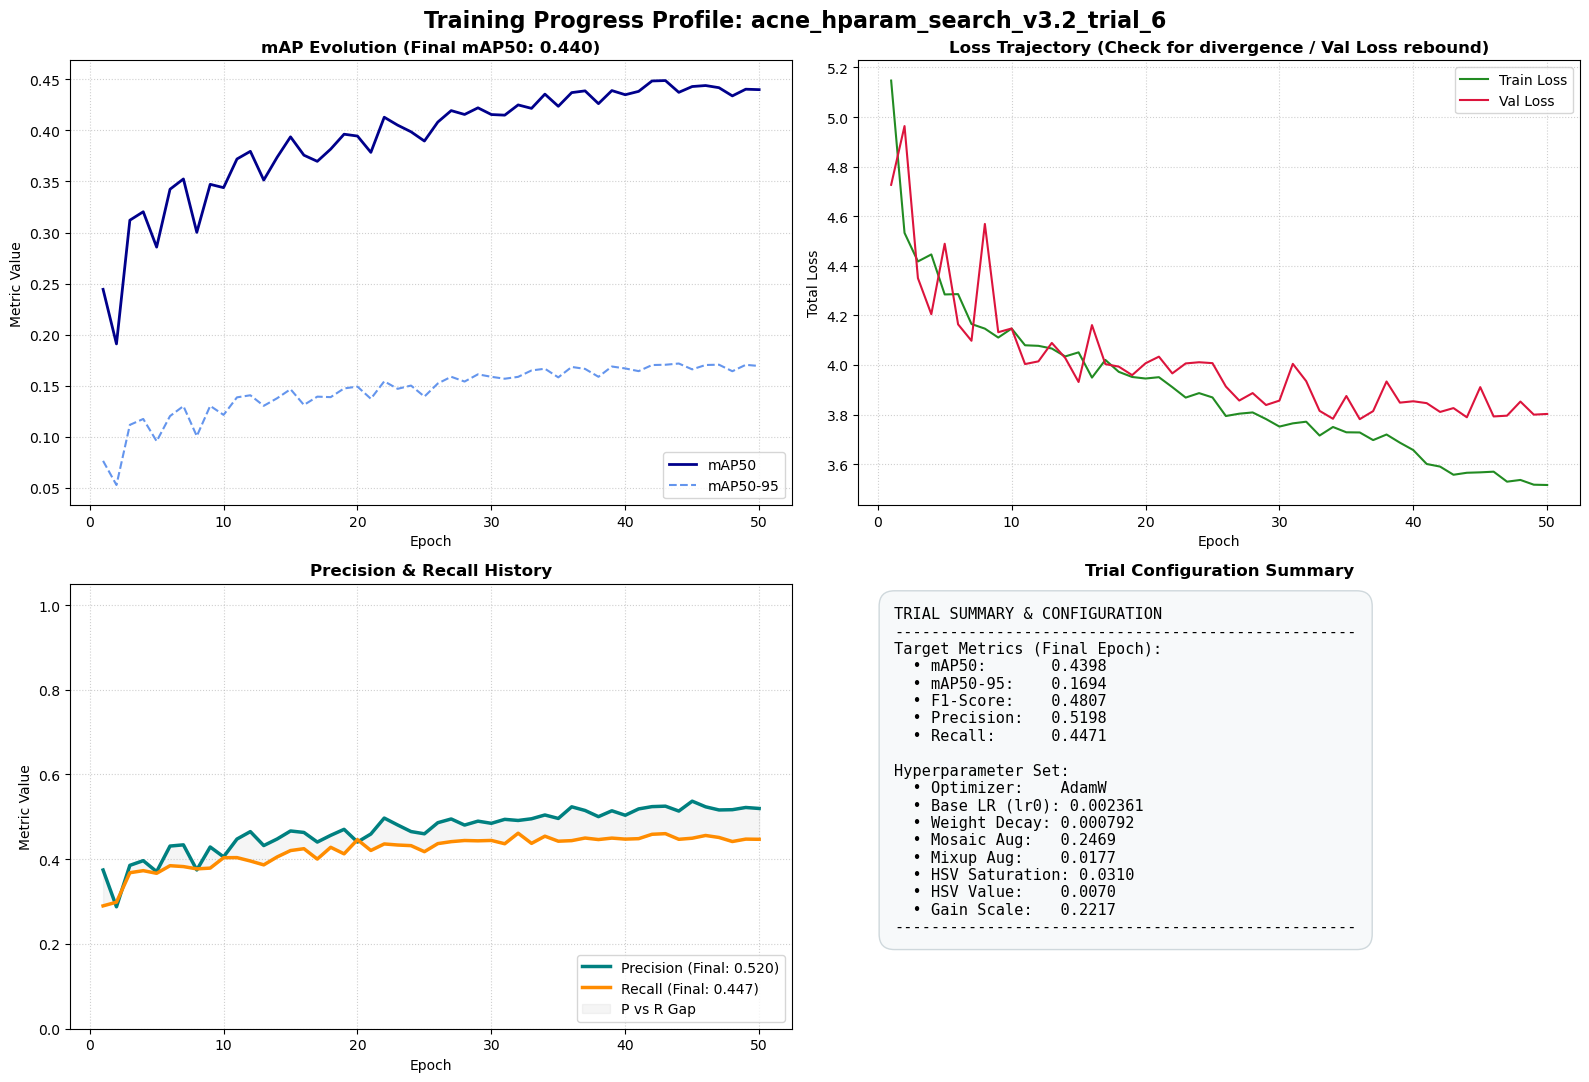

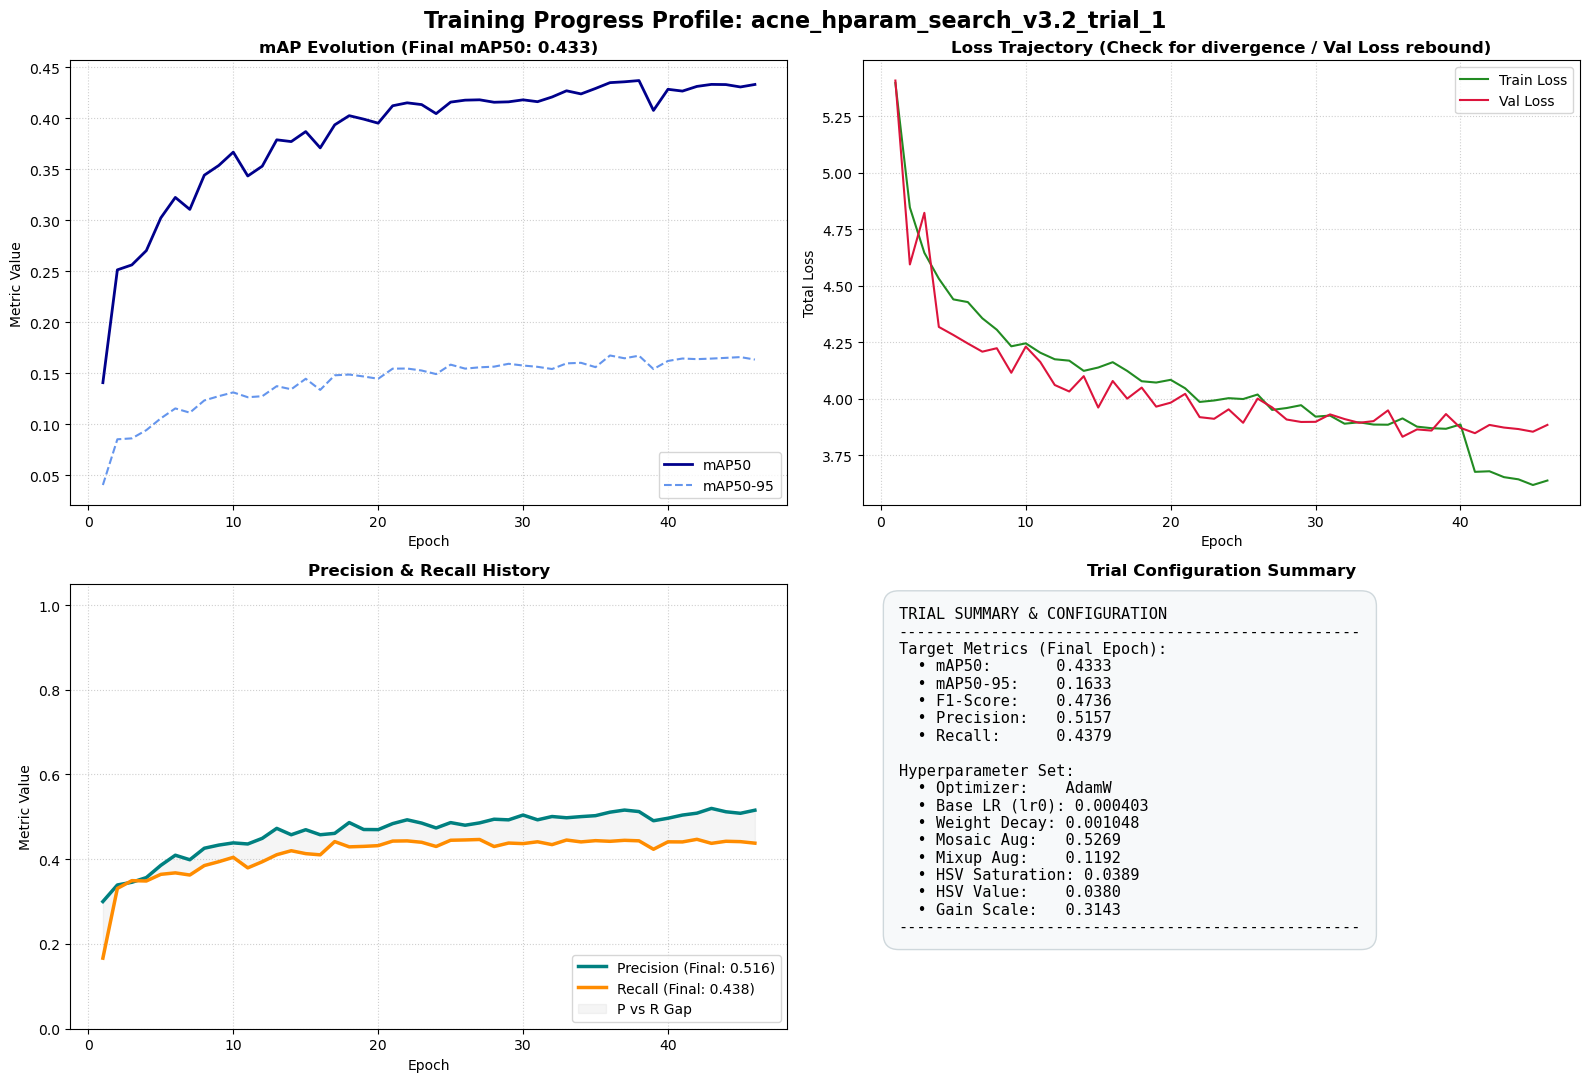

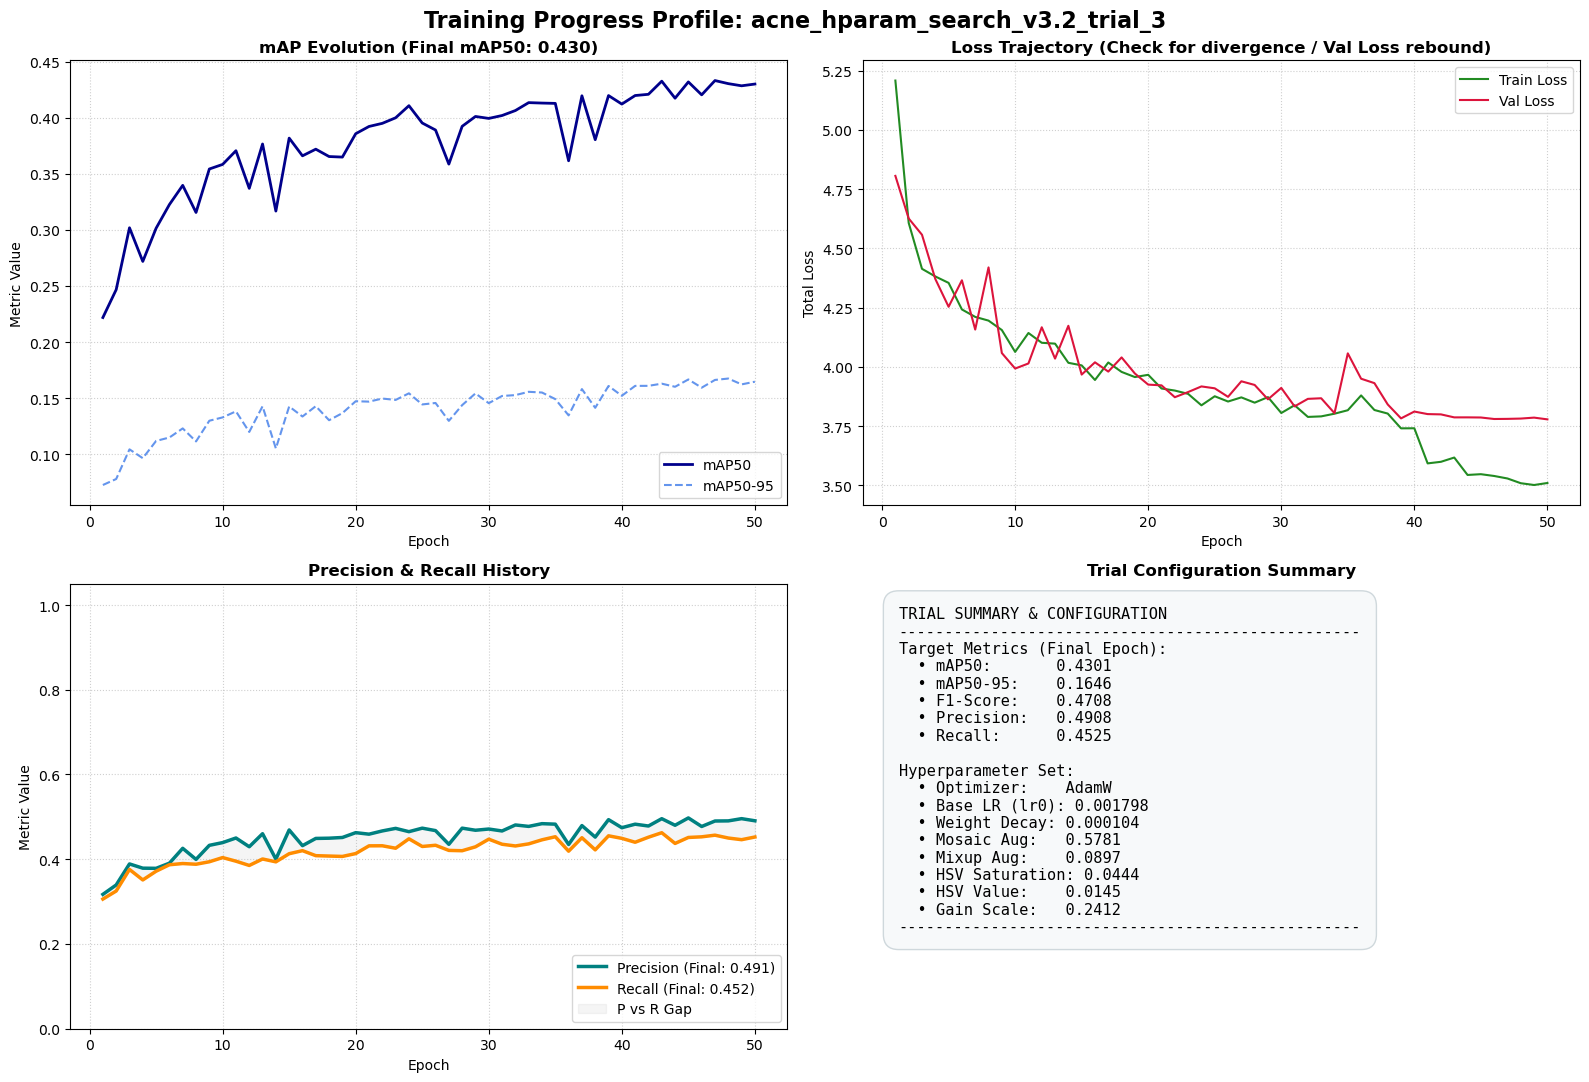

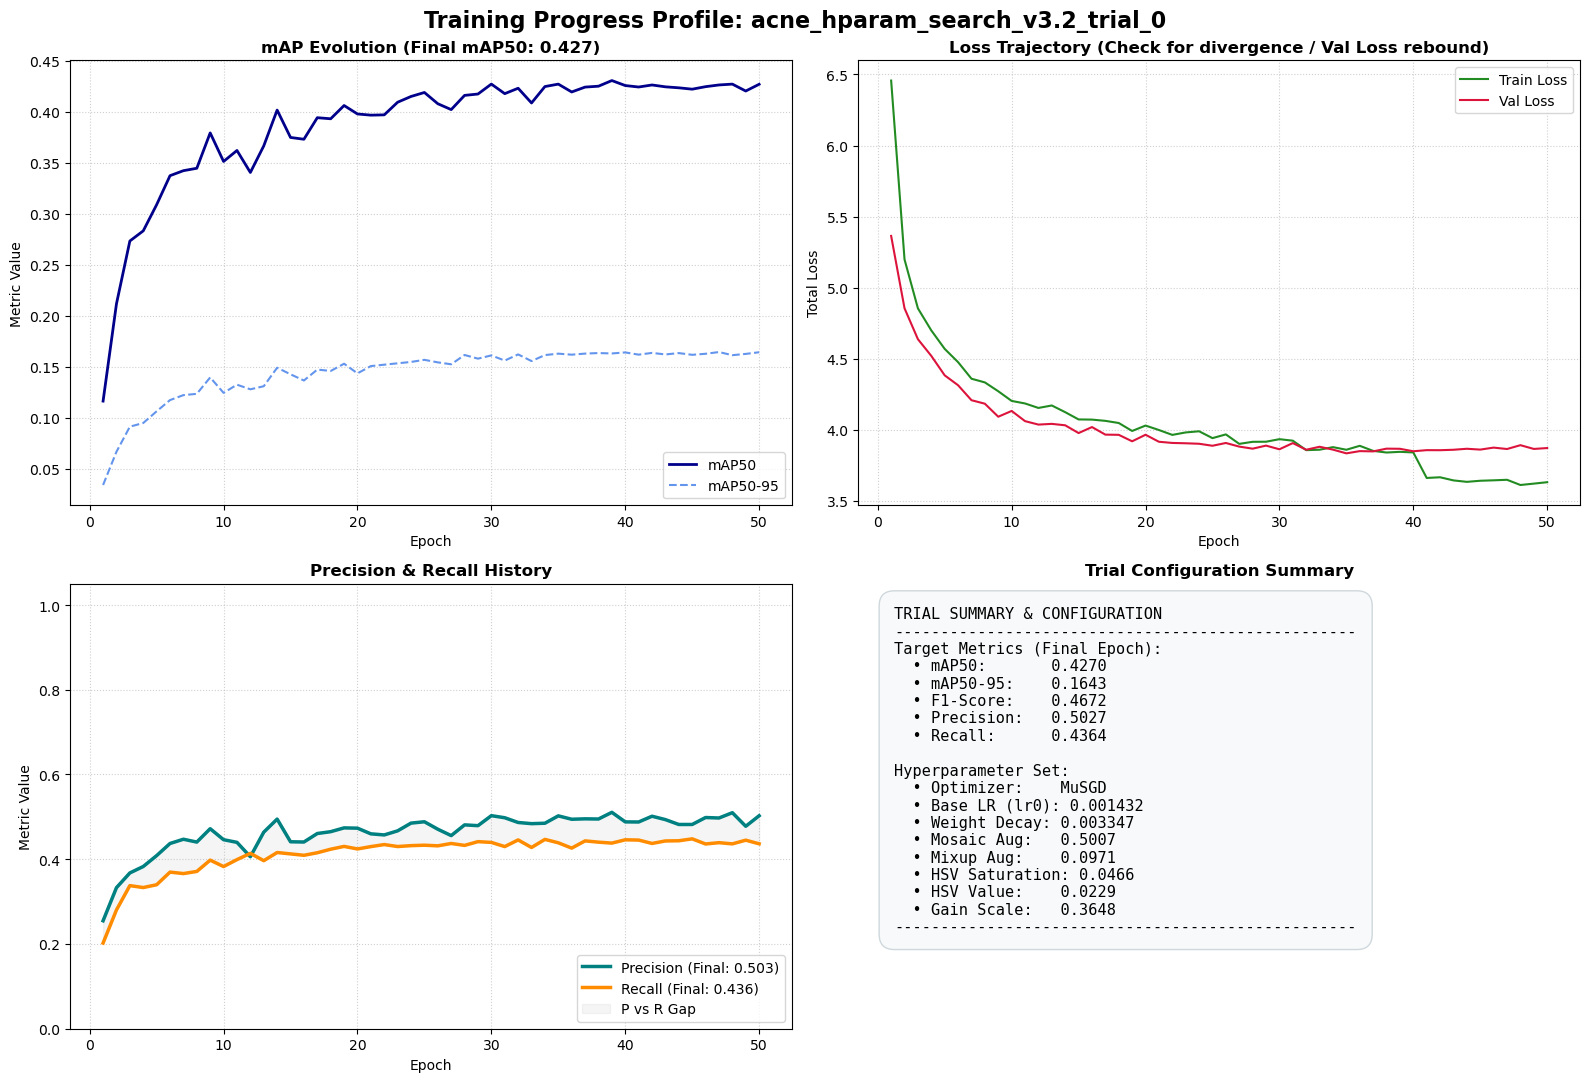

In [19]:
print("\nComprehensive Metric and Loss Profiles for Top 5 Trials")

for idx, row in top_5_trials.iterrows():
    t_name = row["trial"]
    res_df = pd.read_csv(study_path / t_name / "results.csv")
    res_df.columns = [c.strip() for c in res_df.columns]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle(f"Training Progress Profile: {t_name}", fontsize=16, fontweight='bold', y=0.98)
    
    # Row 1, Left: mAP Evolution 
    axes[0, 0].plot(res_df["epoch"], res_df["metrics/mAP50(B)"], color="darkblue", linewidth=2, label="mAP50")
    if "metrics/mAP50-95(B)" in res_df.columns:
        axes[0, 0].plot(res_df["epoch"], res_df["metrics/mAP50-95(B)"], color="cornflowerblue", linestyle="--", label="mAP50-95")
        
    axes[0, 0].set_title(f"mAP Evolution (Final mAP50: {row['map50']:.3f})", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Metric Value")
    axes[0, 0].legend(loc="lower right")
    axes[0, 0].grid(True, linestyle=":", alpha=0.6)
    
    # Row 1, Right: Train vs Validation Loss Comparison 
    train_loss_cols = [c for c in ["train/box_loss", "train/cls_loss", "train/dfl_loss"] if c in res_df.columns]
    val_loss_cols = [c for c in ["val/box_loss", "val/cls_loss", "val/dfl_loss"] if c in res_df.columns]
    
    if train_loss_cols and val_loss_cols:
        total_train_loss = res_df[train_loss_cols].sum(axis=1)
        total_val_loss = res_df[val_loss_cols].sum(axis=1)
        
        axes[0, 1].plot(res_df["epoch"], total_train_loss, color="forestgreen", label="Train Loss")
        axes[0, 1].plot(res_df["epoch"], total_val_loss, color="crimson", label="Val Loss")
        axes[0, 1].set_title("Loss Trajectory (Check for divergence / Val Loss rebound)", fontsize=12, fontweight='bold')
    else:
        axes[0, 1].text(0.5, 0.5, "Loss columns missing in results file", ha='center', va='center')
        
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Total Loss")
    axes[0, 1].legend(loc="upper right")
    axes[0, 1].grid(True, linestyle=":", alpha=0.6)
    
    # Row 2, Left: Precision and Recall Evolution 
    p_hist = res_df["metrics/precision(B)"].values
    r_hist = res_df["metrics/recall(B)"].values
    epochs = res_df["epoch"].values
    
    axes[1, 0].plot(epochs, p_hist, color="teal", linewidth=2.5, label=f"Precision (Final: {row['precision']:.3f})")
    axes[1, 0].plot(epochs, r_hist, color="darkorange", linewidth=2.5, label=f"Recall (Final: {row['recall']:.3f})")
    axes[1, 0].fill_between(epochs, p_hist, r_hist, color="gray", alpha=0.08, label="P vs R Gap")
    
    axes[1, 0].set_title("Precision & Recall History", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Metric Value")
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].legend(loc="lower right")
    axes[1, 0].grid(True, linestyle=":", alpha=0.6)
    
    # Row 2, Right: Configuration & Metric Summary Card 
    axes[1, 1].axis('off')
    
    summary_text = (
        f"TRIAL SUMMARY & CONFIGURATION\n"
        f"--------------------------------------------------\n"
        f"Target Metrics (Final Epoch):\n"
        f"  • mAP50:       {row['map50']:.4f}\n"
        f"  • mAP50-95:    {row['map50_95']:.4f}\n"
        f"  • F1-Score:    {row['f1_score']:.4f}\n"
        f"  • Precision:   {row['precision']:.4f}\n"
        f"  • Recall:      {row['recall']:.4f}\n\n"
        f"Hyperparameter Set:\n"
        f"  • Optimizer:    {row['optimizer']}\n"
        f"  • Base LR (lr0): {row['lr0']:.6f}\n"
        f"  • Weight Decay: {row['weight_decay']:.6f}\n"
        f"  • Mosaic Aug:   {row['mosaic']:.4f}\n"
        f"  • Mixup Aug:    {row['mixup']:.4f}\n"
        f"  • HSV Saturation: {row['hsv_s']:.4f}\n"
        f"  • HSV Value:    {row['hsv_v']:.4f}\n"
        f"  • Gain Scale:   {row['scale']:.4f}\n"
        f"--------------------------------------------------"
    )
    
    axes[1, 1].text(
        0.05, 0.95, summary_text, 
        fontsize=11, 
        fontfamily='monospace', 
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=1', facecolor='#f7f9fa', edgecolor='#cfd8dc', alpha=1.0)
    )
    axes[1, 1].set_title("Trial Configuration Summary", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

### Cell below is expotrs hyperparameters - it extracts specific settings from an Optuna database and saves them to a YAML file for final model training

In [20]:
STUDY_FOLDER = "acne_hparam_study_v3.2"
STUDY_NAME = "acne_hparam_search_v3.2"
SELECTED_TRIAL_NUMBER = 14  # index of the trial to export 

db_path = RUNS_DIR / STUDY_FOLDER / f"{STUDY_NAME}.db"
storage_url = f"sqlite:///{db_path.resolve()}"

try:
    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=storage_url
    )
except Exception as e:
    print(f"Error loading study: {e}")
    print(f"Check if database exists at: {db_path}")
    raise

trial = study.trials[SELECTED_TRIAL_NUMBER]

if trial.state != optuna.trial.TrialState.COMPLETE:
    print(f"WARNING: Trial {SELECTED_TRIAL_NUMBER} state is {trial.state.name}")
    print("Parameters might be incomplete or the trial failed.")

params_to_save = trial.params

metadata = {
    "trial_index": SELECTED_TRIAL_NUMBER,
    "mAP50": trial.values[0] if trial.values else "N/A",
    "state": trial.state.name
}

full_config = {**params_to_save}

save_name = f"params_{STUDY_NAME}_trial_{SELECTED_TRIAL_NUMBER}.yaml"
save_path = RUNS_DIR / STUDY_FOLDER / save_name

with open(save_path, "w") as f:
    yaml.dump(full_config, f, default_flow_style=False, sort_keys=False)

print(f"Successfully exported parameters to: {save_path}")
print(yaml.dump(full_config, sort_keys=False))

Parameters might be incomplete or the trial failed.
Successfully exported parameters to: D:\studia\DermaAI\Models\runs\acne_hparam_study_v3.2\params_acne_hparam_search_v3.2_trial_14.yaml
lr0: 0.0012578355505042395
weight_decay: 0.005157769895932762
mosaic: 0.20548245350470415
mixup: 0.07473415023930467
translate: 0.09528151387192053
hsv_s: 0.001233806157291295
hsv_v: 0.018702133189155156
scale: 0.10775188997103605
degrees: 1.5876795049155819
erasing: 0.018870674790565548



## Final Model Analysis

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from config import RUNS_DIR

RUN_NAME = "acne_train_production_v3.2"
RUN_DIR = RUNS_DIR / RUN_NAME
RESULTS_FILE = RUN_DIR / "results.csv"

if not RESULTS_FILE.exists():
    raise FileNotFoundError(f"Missing results file: {RESULTS_FILE}")

df = pd.read_csv(RESULTS_FILE)
df.columns = df.columns.str.strip() 

print(f"Loaded training data for: {RUN_NAME}")
print(f"Epochs trained: {len(df)}")



Loaded training data for: acne_train_production_v3.2
Epochs trained: 44


BEST EPOCH

epoch with best detection quality (highest recall)

In [22]:
best_epoch_idx = df["metrics/recall(B)"].idxmax()
best_metrics = df.loc[best_epoch_idx, [
    "metrics/precision(B)", 
    "metrics/recall(B)", 
    "metrics/mAP50(B)", 
    "metrics/mAP50-95(B)"
]]

print(f"Best Epoch: {best_epoch_idx}")
print(best_metrics)

Best Epoch: 38
metrics/precision(B)    0.50025
metrics/recall(B)       0.46383
metrics/mAP50(B)        0.44438
metrics/mAP50-95(B)     0.17223
Name: 38, dtype: float64


LOSS CURVES

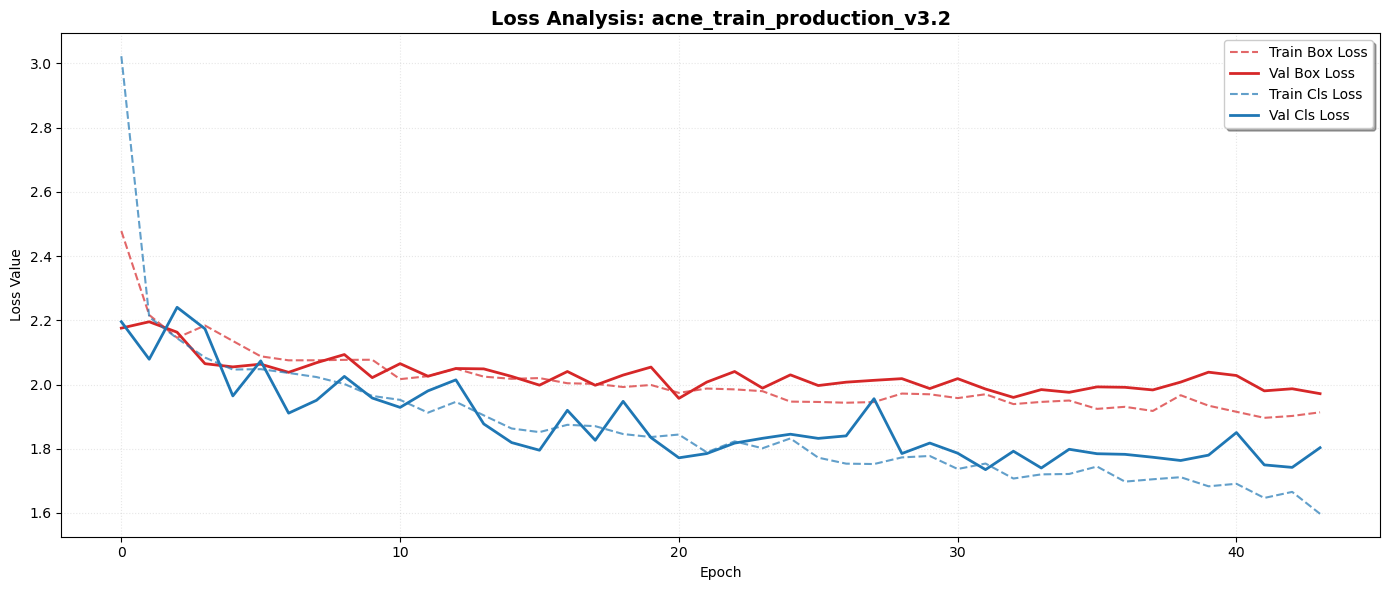

In [23]:
plt.figure(figsize=(14, 6))

# Box Loss: measures how accurately the model draws the boxes
plt.plot(df["train/box_loss"], label="Train Box Loss", color='tab:red', linestyle='--', alpha=0.7)
plt.plot(df["val/box_loss"], label="Val Box Loss", color='tab:red', linewidth=2)

# Class Loss: measures how accurately the model identifies the acne type (not used for now)
plt.plot(df["train/cls_loss"], label="Train Cls Loss", color='tab:blue', linestyle='--', alpha=0.7)
plt.plot(df["val/cls_loss"], label="Val Cls Loss", color='tab:blue', linewidth=2)

plt.title(f"Loss Analysis: {RUN_NAME}", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")


plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

# Parallel Trends: If both dashed and solid lines drop together -> Good learning
# Widening Gap: If train goes down but val goes up -> Overfitting 
# Flat Cls Loss Line: If Cls loss doesnt drop -> Model is struggling to distinguish classes
# Noisy Lines: If Val loss jumps wildly -> Learning rate might be too high

MAIN METRICS

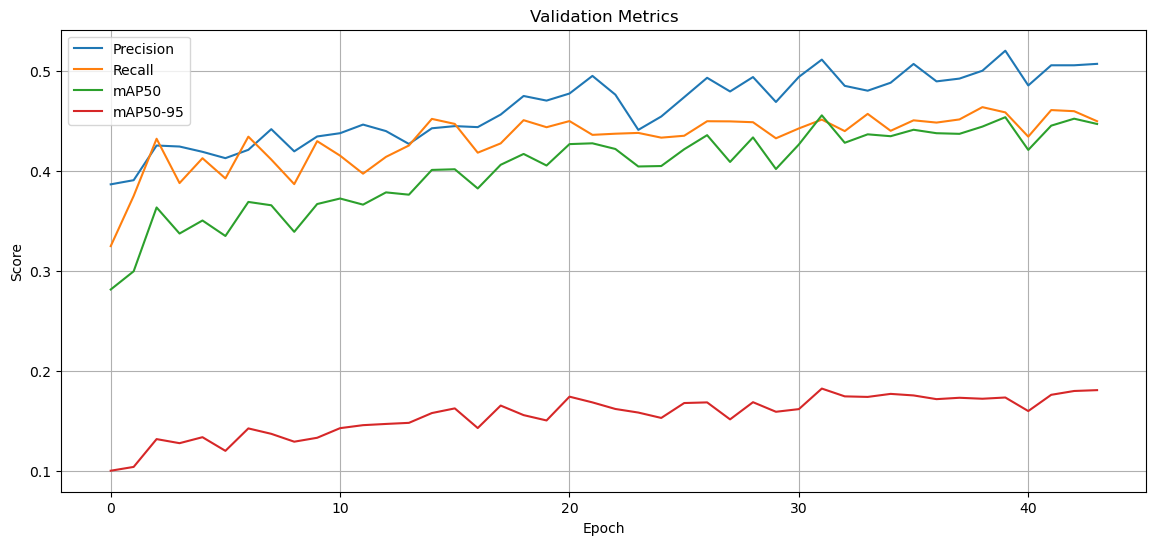

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(df["metrics/precision(B)"], label="Precision")
plt.plot(df["metrics/recall(B)"], label="Recall")
plt.plot(df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

LEARNING RATE

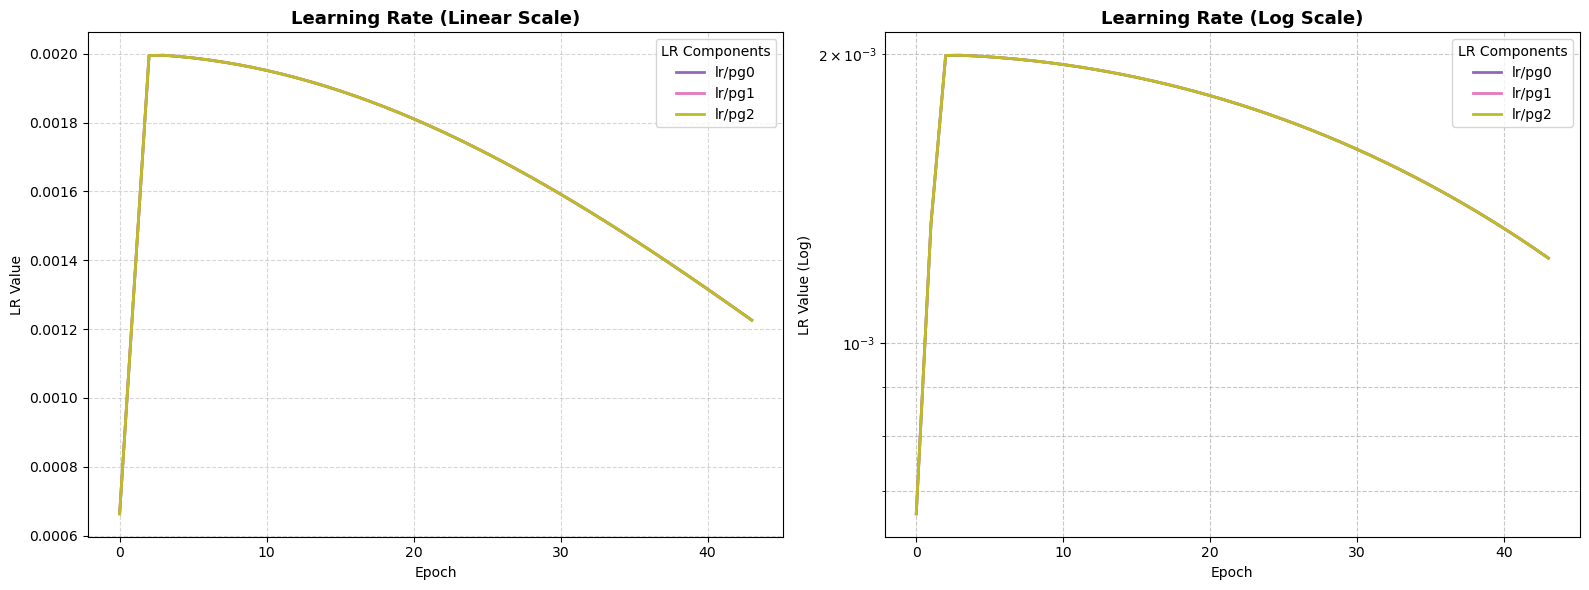

In [25]:
# Learning rate schedule

lr_cols = [c for c in df.columns if "lr/" in c]

if lr_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = ['tab:purple', 'tab:pink', 'tab:olive']

    for i, col in enumerate(lr_cols):
        color = colors[i % len(colors)]
        ax1.plot(df[col], label=col, color=color, linewidth=2)
        ax2.plot(df[col], label=col, color=color, linewidth=2)

    # Subplot 1: Linear Scale
    ax1.set_title("Learning Rate (Linear Scale)", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("LR Value")
    ax1.grid(True, which="both", linestyle='--', alpha=0.5)
    ax1.legend(title="LR Components")

    # Subplot 2: Log Scale ( handles very small values)
    ax2.set_yscale('log')
    ax2.set_title("Learning Rate (Log Scale)", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("LR Value (Log)")
    ax2.grid(True, which="both", linestyle='--', alpha=0.7)
    ax2.legend(title="LR Components")

    plt.tight_layout()
    plt.show()

# The LR schedule is well-configured

GENERALIZATION GAP

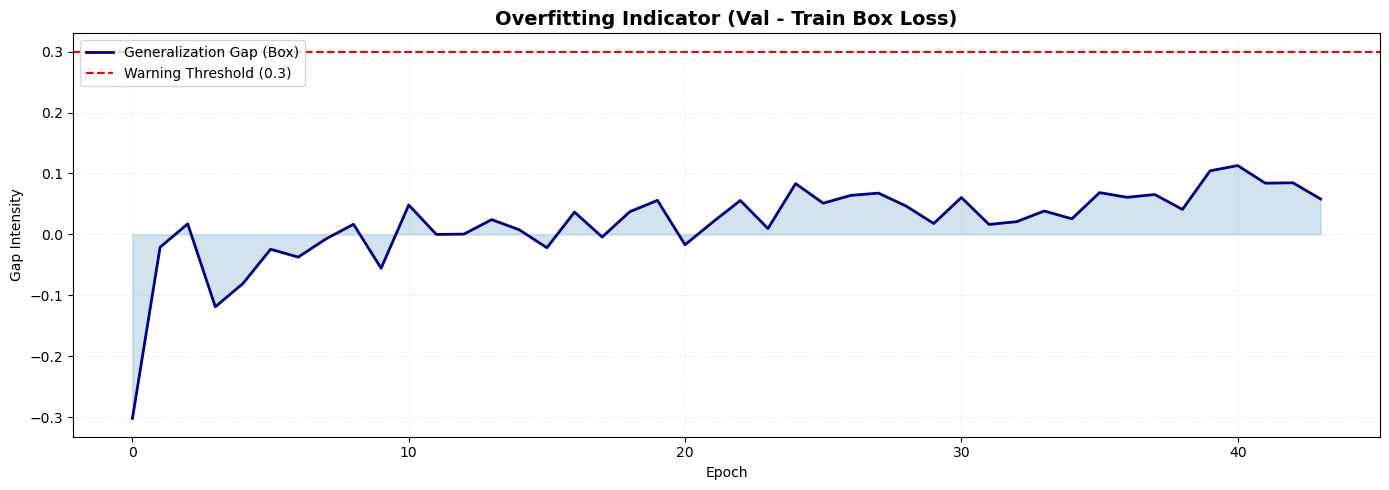

In [ ]:
# Difference between validation and training loss
# Positive gap -> possible overfitting
# Stable/low gap -> good generalization

if "train/box_loss" in df.columns and "val/box_loss" in df.columns:
    gap = df["val/box_loss"] - df["train/box_loss"]
    
    plt.figure(figsize=(14, 5))
    plt.fill_between(range(len(gap)), gap, alpha=0.2, color='tab:blue')
    plt.plot(gap, color='darkblue', linewidth=2, label="Generalization Gap (Box)")
    
    # Critical Overfitting Threshold - if gap exceeds this, model is likely memorizing training data
    plt.axhline(y=0.3, color='red', linestyle='--', label="Warning Threshold (0.3)")
    
    plt.title("Overfitting Indicator (Val - Train Box Loss)", fontsize=14, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("Gap Intensity")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3, linestyle=':')
    plt.tight_layout()
    plt.show()

    # SHOULD BE 0.1 - 0.3 
    # model memorized the training photos instead of learning (data leakage!!!) 